## Association Rules

Application of popular association rules algorithms such as Apriori and FP-growth on some datasets.

### Transaction Data Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# printing options
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)


In [3]:
# Load Online Retail dataset
df = pd.read_excel("Online_Retail.xlsx")

# Inspect first few rows
print(df.head())
print(df.columns)

  InvoiceNo StockCode                          Description  Quantity         InvoiceDate  UnitPrice  CustomerID         Country
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6 2010-12-01 08:26:00       2.55     17850.0  United Kingdom
1    536365     71053                  WHITE METAL LANTERN         6 2010-12-01 08:26:00       3.39     17850.0  United Kingdom
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8 2010-12-01 08:26:00       2.75     17850.0  United Kingdom
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6 2010-12-01 08:26:00       3.39     17850.0  United Kingdom
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6 2010-12-01 08:26:00       3.39     17850.0  United Kingdom
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'], dtype='object')


In [4]:
# Discard all rows with null values in description, customerID
# Remove all records with invoiceNo starting with C

df = df.dropna(subset=['Description', 'CustomerID'])
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

df = df[~df['InvoiceNo'].str.startswith('C')]

In [5]:
# Remove records with description Postage
# Discard records with invoiceNo having only one item

df = df[~df['Description'].str.upper().str.contains('POSTAGE')]

item_count = df.groupby('InvoiceNo')['Description'].nunique()
invoices_multi_item = item_count[item_count > 1].index
df = df[df['InvoiceNo'].isin(invoices_multi_item)]

df.shape


(395397, 8)

In [6]:
# Merge different invoices for same customer
# Remove items which has quantity sold less than 1000


df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate_only'] = df['InvoiceDate'].dt.date
df['MergedInvoice'] = df['CustomerID'].astype(str) + "_" + df['InvoiceDate_only'].astype(str)


total_qty = df.groupby('Description')['Quantity'].sum()
popular_items = total_qty[total_qty >= 1000].index  
df = df[df['Description'].isin(popular_items)]



In [7]:
# Records only related to UK

df_uk = df[df['Country'] == 'United Kingdom'].copy()
print("Rows after filtering to UK:", df_uk.shape[0])


Rows after filtering to UK: 262527


In [8]:
# Create datagrame with invoiceNo as an index, items as columns
# 1 row should show the quantity of each item purchased for every transaction and 0 for unpurchased items
# Convert quantity to 1 - hot encoding to represent an item purchased

basket = (df_uk
          .groupby(['MergedInvoice', 'Description'])['Quantity']
          .sum()
          .unstack(fill_value=0))

# Hot encoding
transactions = basket.applymap(lambda x: 1 if x > 0 else 0)

df_uk.head()

C:\Users\ragul\AppData\Local\Temp\ipykernel_22656\2889043216.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  transactions = basket.applymap(lambda x: 1 if x > 0 else 0)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDate_only,MergedInvoice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,17850.0_2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,17850.0_2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,17850.0_2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,17850.0_2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,17850.0_2010-12-01


### Association Rules

In [9]:
# Using Apriori alg generate frequent itemsets with a minimum support = 2%

min_support = 0.02
frequent_ap = apriori(transactions, min_support=min_support, use_colnames=True)
frequent_ap = frequent_ap.sort_values('support', ascending=False).reset_index(drop=True)
print("Number of frequent itemsets (Apriori):", frequent_ap.shape[0])
frequent_ap.head(20)

c:\Users\ragul\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets (Apriori): 320


,support,itemsets
0,0.129270,(WHITE HANGING HEART T-LIGHT HOLDER)
1,0.099888,(JUMBO BAG RED RETROSPOT)
2,0.097287,(REGENCY CAKESTAND 3 TIER)
3,0.091031,(ASSORTED COLOUR BIRD ORNAMENT)
4,0.089273,(PARTY BUNTING)
5,0.078588,(LUNCH BAG RED RETROSPOT)
6,0.069942,(SET OF 3 CAKE TINS PANTRY DESIGN )
7,0.069450,(LUNCH BAG BLACK SKULL.)
8,0.065654,(NATURAL SLATE HEART CHALKBOARD )
9,0.065303,(PAPER CHAIN KIT 50'S CHRISTMAS )


Observations and results

Apriori Algorithm
- This alg finds frequent itemsets and helps discovering association rules. From frequent itemsets, the association rues can be created.
- It uses bottom-up approach:
    1. Find frequent 1-temsets = looks for single items that appear often enough
    2. Generate candidate 2-itemsets = combine frequent 1-itemsets into pairs and count how often they appear
    3. Filter by support = keep only pairs that meet the minimum support
    4. Repeat = combine previous frequent itemsets and filter by support


- support = the itemset appears in %% of all transactions
- confidence = how oftern B occurs when A occurs
- lift measures how much more likely B occurs with A than by chance


This dataset
- support = the proportion of transactions that include the itemset. For example: 0.1292 for white hanging heart t-light holder means that ~ 12.9% of all transactions included this item
- itemsets = this is the actual product or combination of products

Observations
- the most frequent item is white hanging heart t-light holder with a support of ~ 13%
- these decrease gradually
- items with high support are popular and likely to appear in rules

In [10]:
# Using the FP-Growth alg to generate frequent itemsets with min support = 2%
# How do these results compare to Apriori's results?

frequent_fp = fpgrowth(transactions, min_support=min_support, use_colnames=True)
frequent_fp = frequent_fp.sort_values('support', ascending=False).reset_index(drop=True)
print("Number of frequent itemsets (FP-Growth):", frequent_fp.shape[0])
print()


# comparison
set_ap = set(frozenset(x) for x in frequent_ap['itemsets'])
set_fp = set(frozenset(x) for x in frequent_fp['itemsets'])
print("Same itemsets from apriori vs FPGrowth : ", set_ap == set_fp)


c:\Users\ragul\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets (FP-Growth): 320

Same itemsets from apriori vs FPGrowth :  True


Observations and Results

Frequent Pattern Tree
- it compresses the dataset into a tree and mines itemsets directly from it, this makes it much faster

The results
- both alg produced the exact same set of frequent itemsets, they only differ in how they are finding them:
    1. Apriori generates and tests candidates level by level
    2. FP compresses the dataset and mines patterns without generating candidates
- the number of itemsets is the same and support values are identical
- the difference was in the runtime

In [11]:
# Using frequent itemsets, find all association rules with a minimum confidence = 50%

min_conf = 0.5
rules_ap = association_rules(frequent_ap, metric="confidence", min_threshold=min_conf)
rules_ap = rules_ap.sort_values(['confidence', 'support'], ascending=[False, False]).reset_index(drop=True)
print("Number of rules with confidence >= 0.5:", len(rules_ap))
rules_ap[['antecedents','consequents','support','confidence','lift']].head(20)


Number of rules with confidence >= 0.5: 44


,antecedents,consequents,support,confidence,lift
0,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.023759,0.891821,20.866841
1,"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.023759,0.842893,17.897004
2,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.028188,0.828512,19.385555
3,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.026641,0.783058,16.626539
4,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.033249,0.777961,16.518308
5,(WOODEN STAR CHRISTMAS SCANDINAVIAN),(WOODEN HEART CHRISTMAS SCANDINAVIAN),0.021088,0.751880,24.645716
6,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.032054,0.731942,14.186117
7,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.023759,0.714588,21.003564
8,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.033249,0.705970,16.518308
9,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.023759,0.698347,21.003564


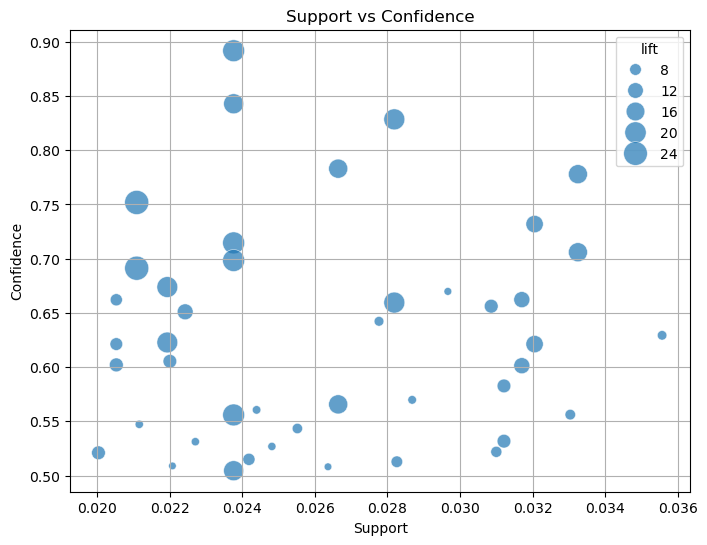

In [12]:
# Scatter plot

plt.figure(figsize=(8,6))
sns.scatterplot(data=rules_ap, x='support', y='confidence', size='lift', sizes=(30,300), alpha=0.7)
plt.title('Support vs Confidence')  # (size=lift)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True)
plt.show()

Observations and Results

Association Rules
- describe relationships between items in transactional data
- Antecedent = items that appear first
- Consequent = items that are likely to appear with the antecedent

For example: (PINK REGENCY TEACUP AND SAUCER) → (GREEN REGENCY TEACUP AND SAUCER)
- this means that if a customer buys the pink regency teacup, they are also likely to buy the green regency teacup.

Metrics
- support = fraction of transactions that contain both antecedent and consequent: ~2.8% of all transactions include both pink and green teacups
- confidence = probability that the consequent is purchased given the antecedent is purchased: if a customer buys the pink teacup, there is an ~82.8% chance they also buy the green teacup
- lift = measures how much more likely the consequent is purchased with the antecedent than by chance: 19.38 is very strong association between piink and green teacups

Rules
1. start with frequent itemsets = these are the combinations of items that meet the min support threshold
2. Generate all possible rules = for each frequent itemset split it into all possible pairs
3. Filter by min confidence
4. Sort and analyze rules

In [ ]:
# Discuss rules when the support is > 2.8% and cofidence > 50%

rules_strong = rules_ap[(rules_ap['support'] > 0.028) & (rules_ap['confidence'] > 0.5)].copy()
rules_strong['antecedent_str'] = rules_strong['antecedents'].apply(lambda s: ', '.join(list(s)))
rules_strong['consequent_str'] = rules_strong['consequents'].apply(lambda s: ', '.join(list(s)))
cols = ['antecedent_str','consequent_str','support','confidence','lift']
print("Rules with support > 2.8% and confidence > 50%:")
print(rules_strong[cols].sort_values(['support','confidence'], ascending=False))


Rules with support > 2.8% and confidence > 50%:
                        antecedent_str                      consequent_str   support  confidence       lift
19             JUMBO BAG PINK POLKADOT             JUMBO BAG RED RETROSPOT  0.035569    0.629353   6.300619
4      GREEN REGENCY TEACUP AND SAUCER    ROSES REGENCY TEACUP AND SAUCER   0.033249    0.777961  16.518308
8     ROSES REGENCY TEACUP AND SAUCER      GREEN REGENCY TEACUP AND SAUCER  0.033249    0.705970  16.518308
30             LUNCH BAG PINK POLKADOT             LUNCH BAG RED RETROSPOT  0.033038    0.556213   7.077537
6   GARDENERS KNEELING PAD CUP OF TEA    GARDENERS KNEELING PAD KEEP CALM   0.032054    0.731942  14.186117
22   GARDENERS KNEELING PAD KEEP CALM   GARDENERS KNEELING PAD CUP OF TEA   0.032054    0.621253  14.186117
13          ALARM CLOCK BAKELIKE GREEN           ALARM CLOCK BAKELIKE RED   0.031703    0.662261  12.561774
25           ALARM CLOCK BAKELIKE RED           ALARM CLOCK BAKELIKE GREEN  0.031703    

Observations and Rules

- support = only keeeping the rules that appear in at least 2.8% of all transactions, this ensures that the patterns arent rare
- confidence = only keeping rules where the consequent occurs at least half of the time when the antecedent appears
- Overall this gives the most reliable and frequent buying patterns in dataset

Overview of the results
- JUMBO BAG PINK POLKADOT → JUMBO BAG RED RETROSPOT (support 3.6%, confidence 63%) = cunstomers who buy the pink variant often buy the red one too, suggesting the customers like matching color themes. Show customers matching items or offer discounts on complete sets.
- GREEN REGENCY TEACUP AND SAUCER → ROSES REGENCY TEACUP AND SAUCER (3.3% support, confidence 78%) = customers buy multiple Regency teacups from the same design line, meaning strong crosspurchasing behaviour among tea set items. Cross-promote different colour versiions together or offer bundle deals.
- HEART OF WICKER LARGE → HEART OF WICKER SMALL (support 3%, confidence 51%) = customers who buy one size often buy another size, consistent gift or home decor pattern. 
- GARDENERS KNEELING PAD CUP OF TEA → GARDENERS KNEELING PAD KEEP CALM (support 3%, confidence 73%) = people purchase multiple kneeling pad designs together. Bundle color variants or display them side by side online.
- ALARM CLOCK BAKELIKE GREEN → ALARM CLOCK BAKELIKE RED (support 3%, confidence 66%) = suggests customers might be buying multiple colours of the same alarm clock. Customers who purchase one picture frame style tend to buy another.
- PAPER CHAIN KIT VINTAGE CHRISTMAS → PAPER CHAIN KIT 50'S CHRISTMA (support 3%, confidence 65%) = buyers of one christmas decoration kit often buy another one, very strong christmas shopping pattern. Pair colour variations of decorative items in gift sets.

Overall
- Customers tend to purchase variants or complementary items rather than unrelated ones.
- Overall, these results highlight product complementarity and colour theme shopping behaviour, suggesting potential for cross-selling and product bundling strategies.
- Most rules have lift > 5, which indicates these combinations happen far more often than chance would predict.
- Both of the Algorithms capture the same relationships

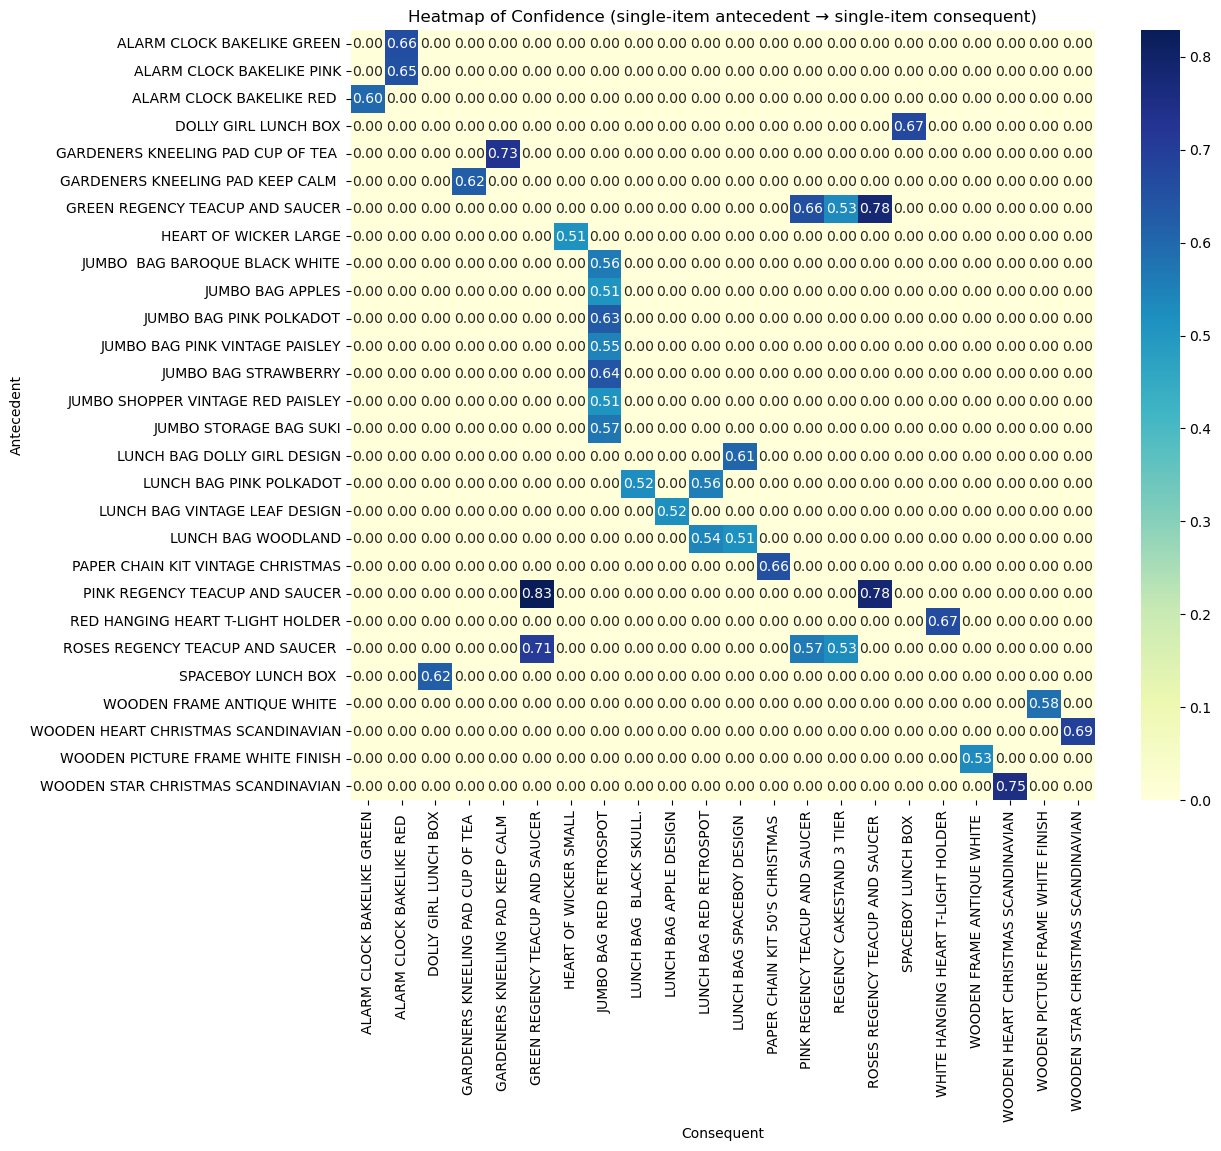

In [ ]:
# The map for most important association rules using pivot() and seaborn heatmap() functions
rules_ap['ant_len'] = rules_ap['antecedents'].apply(lambda x: len(x))
rules_ap['cons_len'] = rules_ap['consequents'].apply(lambda x: len(x))
rules_ap['ant_str'] = rules_ap['antecedents'].apply(lambda s: next(iter(s)) if len(s)==1 else ','.join(list(s)))
rules_ap['cons_str'] = rules_ap['consequents'].apply(lambda s: next(iter(s)) if len(s)==1 else ','.join(list(s)))

rules_single = rules_ap[(rules_ap['ant_len']==1) & (rules_ap['cons_len']==1)].copy()

pivot_conf = rules_single.pivot(index='ant_str', columns='cons_str', values='confidence')

plt.figure(figsize=(12,10))
sns.heatmap(pivot_conf.fillna(0), annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Heatmap of Confidence (single-item antecedent → single-item consequent)')
plt.xlabel('Consequent')
plt.ylabel('Antecedent')
plt.show()


Results

1. Strong Mutual Associations (High Confidence > 0.7):

Green Regency Teacup and Saucer ↔ Roses Regency Teacup and Saucer
- These two items appear together very frequently — confidence values around 0.71–0.78 and a lift over 16.
- Suggests customers often buy both designs together as a set.

Pink Regency Teacup and Saucer → Green Regency Teacup and Saucer (0.83)
- This is one of the strongest directional rules, meaning if someone buys the pink cup, there’s a very high chance they’ll also buy the green version.

2. Moderate but Meaningful Associations (Confidence 0.5–0.7):

JUMBO BAG PINK POLKADOT → JUMBO BAG RED RETROSPOT (0.63)
- Indicates that customers tend to buy multiple color variations of the same product type.

Alarm Clock Bakelike Green ↔ Alarm Clock Bakelike Red (0.60–0.66)
- Customers are buying different color variants of the same alarm clock line.

Gardeners Kneeling Pad CUP OF TEA ↔ KEEP CALM (0.62–0.73)
- Suggests themed gardening products are commonly purchased together.

3. Clusters of Related Products:

- You can see small clusters in the plot — especially for teacups, bags, and clock products.
Each cluster corresponds to a group of items that are stylistically or functionally similar, meaning the Apriori algorithm successfully captured cross-selling opportunities.